<div style="
    display:flex;
    align-items:center;
    background:linear-gradient(90deg, #ffffff, #ffffff);
    border-left:8px solid #c00000;
    width:99%;
    padding:10px 14px;
    border-radius:8px;
    box-sizing:border-box;
    margin:0 0 -10px 0;">
    <span style="color:#c00000;font-size:32px;font-weight:bold;font-family:Arial,sans-serif;">
        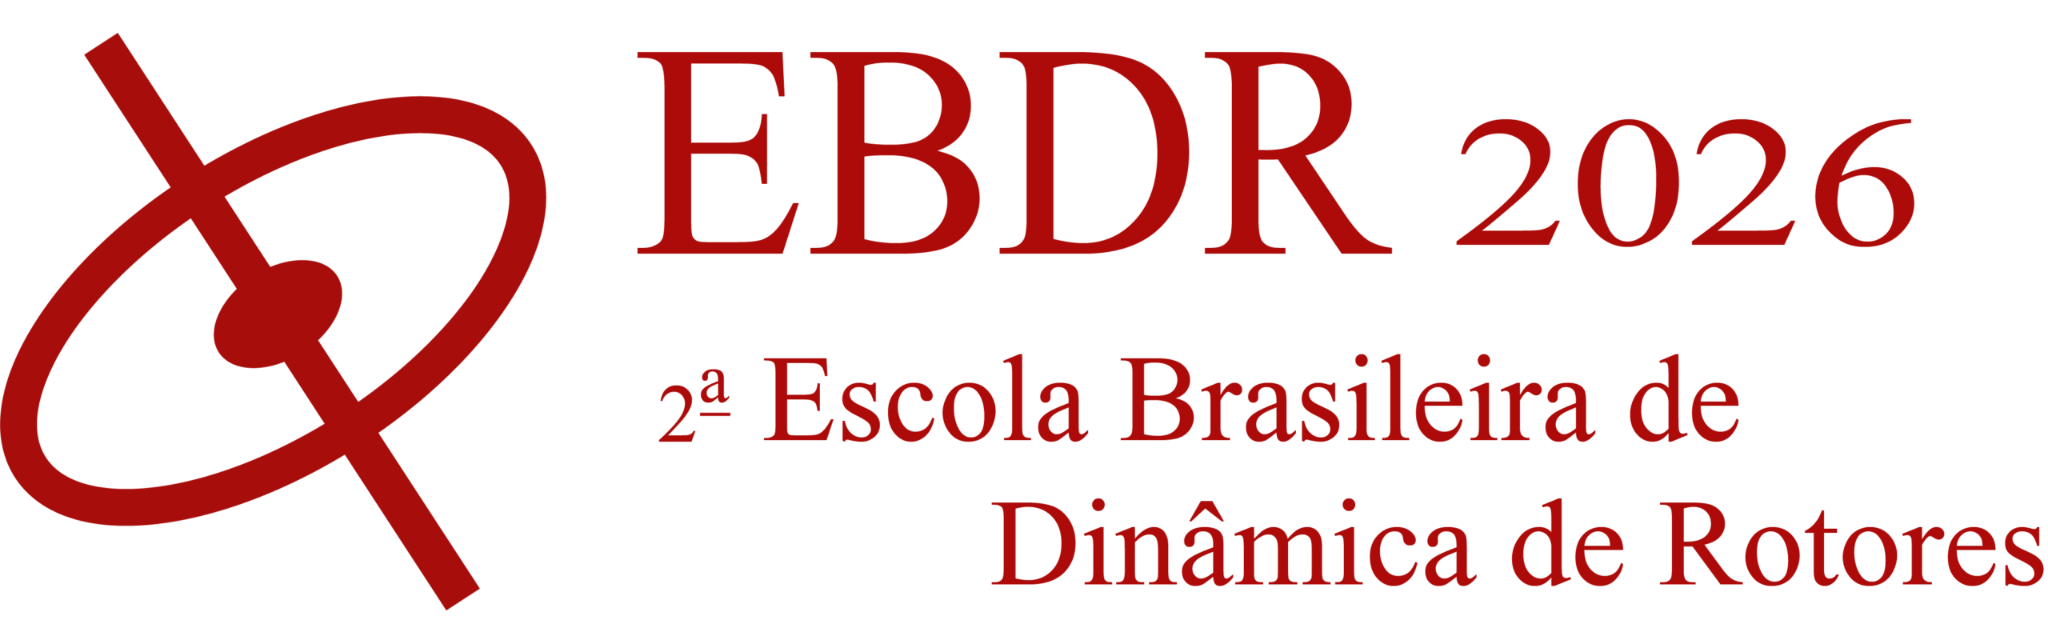&nbsp;&nbsp;Modelagem de Rotor Flexível DTU - 24 Elementos
    </span>
</div>

# Modelagem de Rotor Flexível DTU - 24 Elementos

**Análise Modal, Diagrama de Campbell, Resposta em Frequência, Resposta a Desbalanceamento, Velocidades Críticas e Resposta no Tempo**

**MACHINERY DYNAMICS LECTURES (41514) - MEK/DTU - Ilmar Ferreira Santos**

**Resultados experimentais de referência:** 13.0, 14.9, 33.6, 43.0, 46.0 Hz.

> Discretização mais fina (24 elementos) → melhor convergência dos modos superiores.

> **Nota de modelagem:** este notebook utiliza a formulação ROSS com `n_link` para representar a ligação entre o nó do eixo, o alojamento do mancal e a rigidez do suporte.


<div style="
    display:flex;
    align-items:center;
    background:linear-gradient(90deg, #ffffff, #ffffff);
    border-left:8px solid #c00000;
    width:99%;
    padding:10px 14px;
    border-radius:8px;
    box-sizing:border-box;
    margin:0 0 -10px 0;">
    <span style="color:#c00000;font-size:24px;font-weight:bold;font-family:Arial,sans-serif;">
        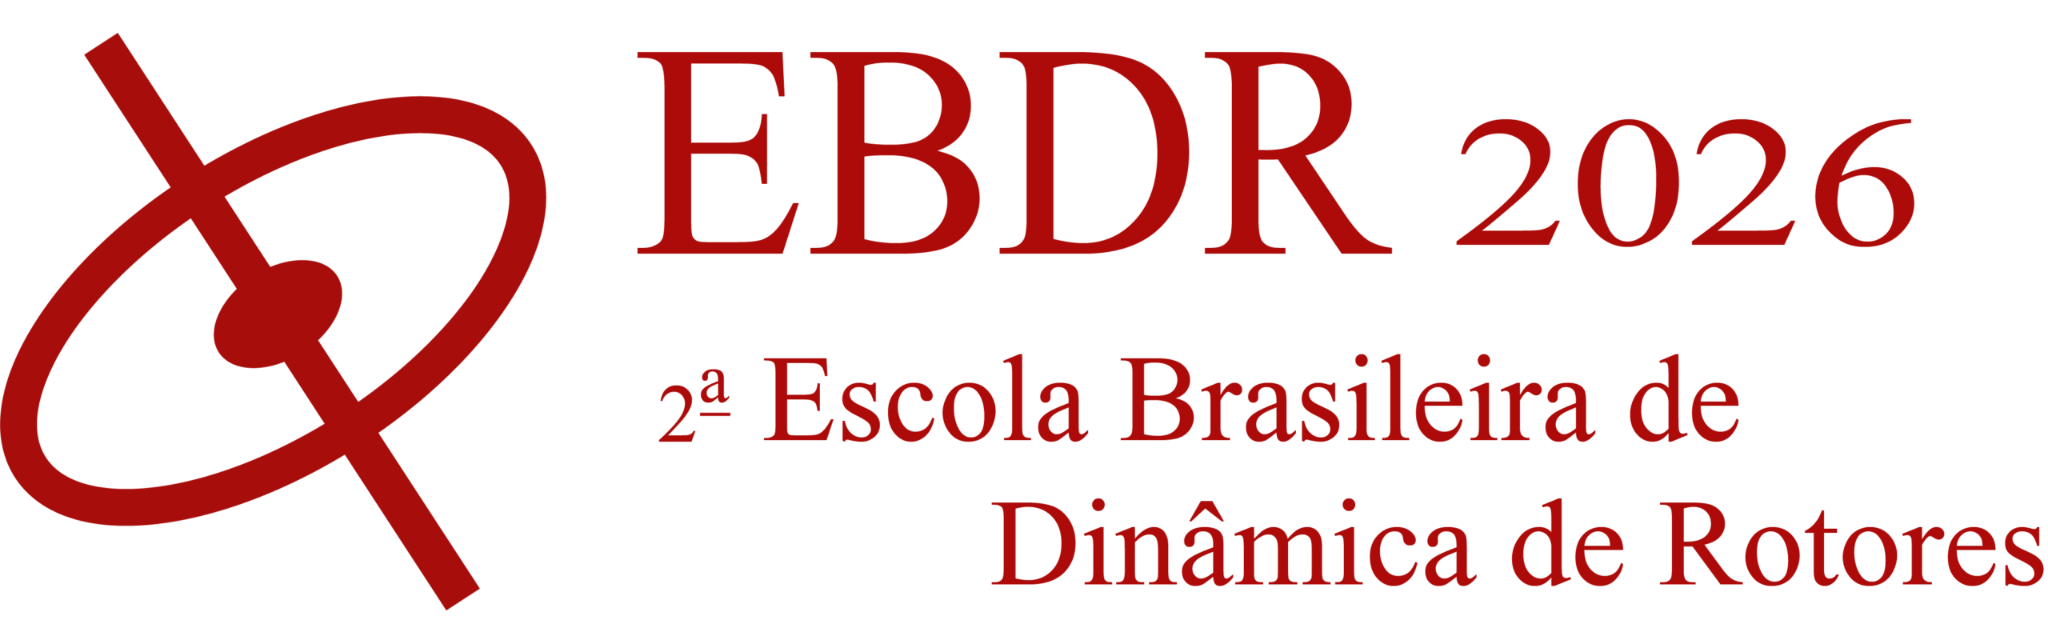&nbsp;&nbsp;2. Introdução teórica
    </span>
</div>

O modelo representa um rotor flexível por elementos finitos de eixo, com dois discos e dois conjuntos de mancais. A análise modal determina as frequências naturais e os modos de vibração do sistema linearizado.

A formulação de rotor do **ROSS (Rotordynamic Open-Source Software)** considera os graus de liberdade associados aos nós e permite incluir efeitos de cisalhamento, inércia rotatória e giroscopia. Para a análise lateral utilizada neste material, o modelo é convertido para 4 DOF por nó.

A discretização do eixo influencia diretamente a representação espacial dos modos. Uma malha mais refinada tende a melhorar a convergência das frequências naturais, especialmente para os modos superiores.

Os cinco valores experimentais de referência do ensaio DTU são **13.0 Hz, 14.9 Hz, 33.6 Hz, 43.0 Hz e 46.0 Hz**. A comparação entre esses valores e os resultados numéricos constitui a etapa principal de validação.


<div style="
    display:flex;
    align-items:center;
    background:linear-gradient(90deg, #ffffff, #ffffff);
    border-left:8px solid #c00000;
    width:99%;
    padding:10px 14px;
    border-radius:8px;
    box-sizing:border-box;
    margin:0 0 -10px 0;">
    <span style="color:#c00000;font-size:24px;font-weight:bold;font-family:Arial,sans-serif;">
        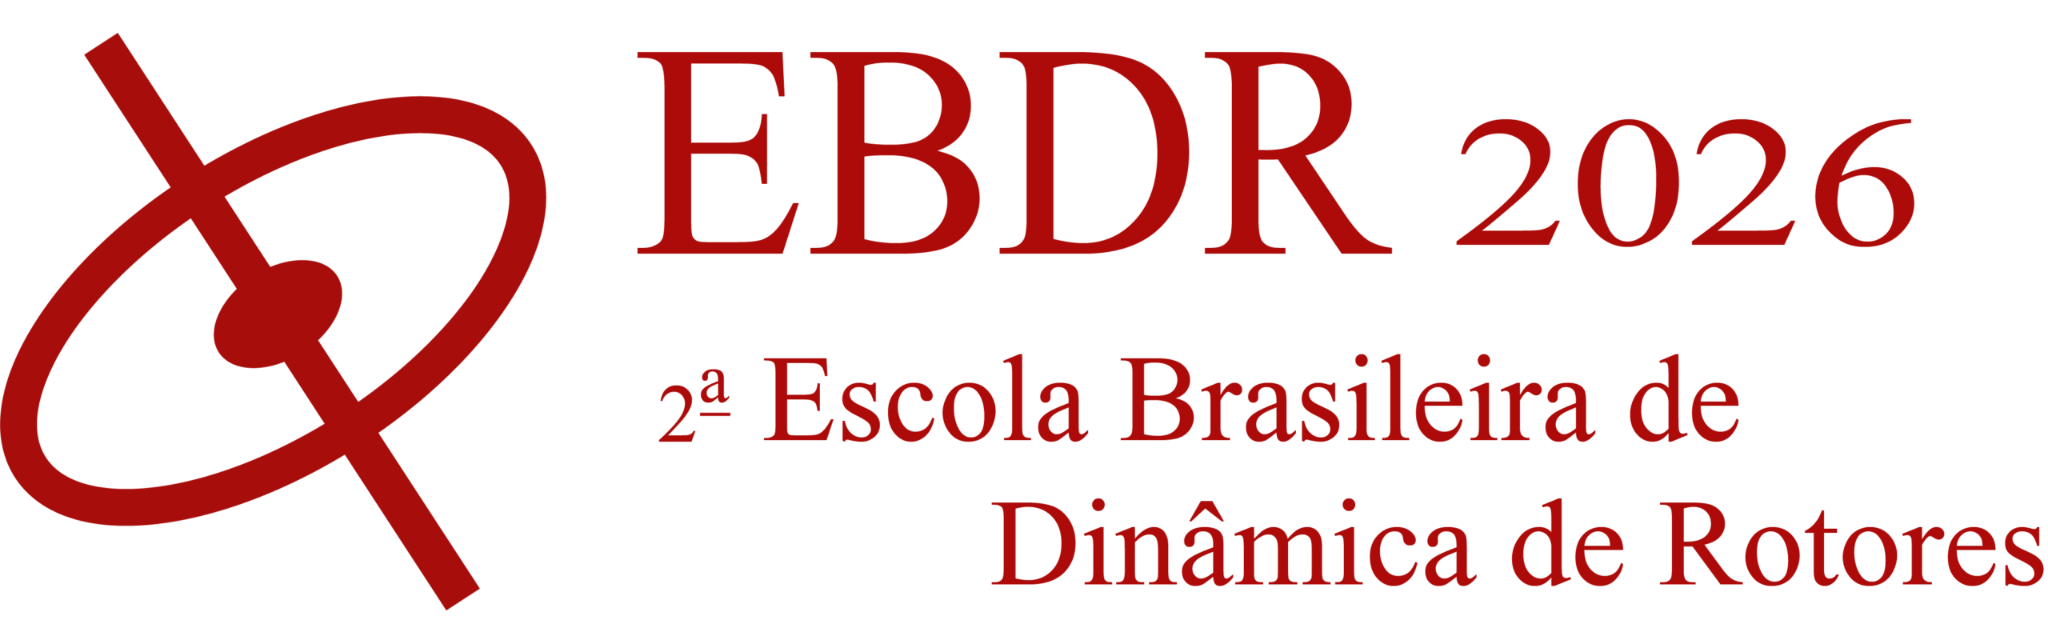&nbsp;&nbsp;3. Inicialização
    </span>
</div>

In [ ]:
import ross as rs
import numpy as np
import pandas as pd
import plotly.graph_objects as go
from scipy import linalg as la
from ross.utils import convert_6dof_to_4dof


<div style="
    display:flex;
    align-items:center;
    background:linear-gradient(90deg, #ffffff, #ffffff);
    border-left:8px solid #c00000;
    width:99%;
    padding:10px 14px;
    border-radius:8px;
    box-sizing:border-box;
    margin:0 0 -10px 0;">
    <span style="color:#c00000;font-size:24px;font-weight:bold;font-family:Arial,sans-serif;">
        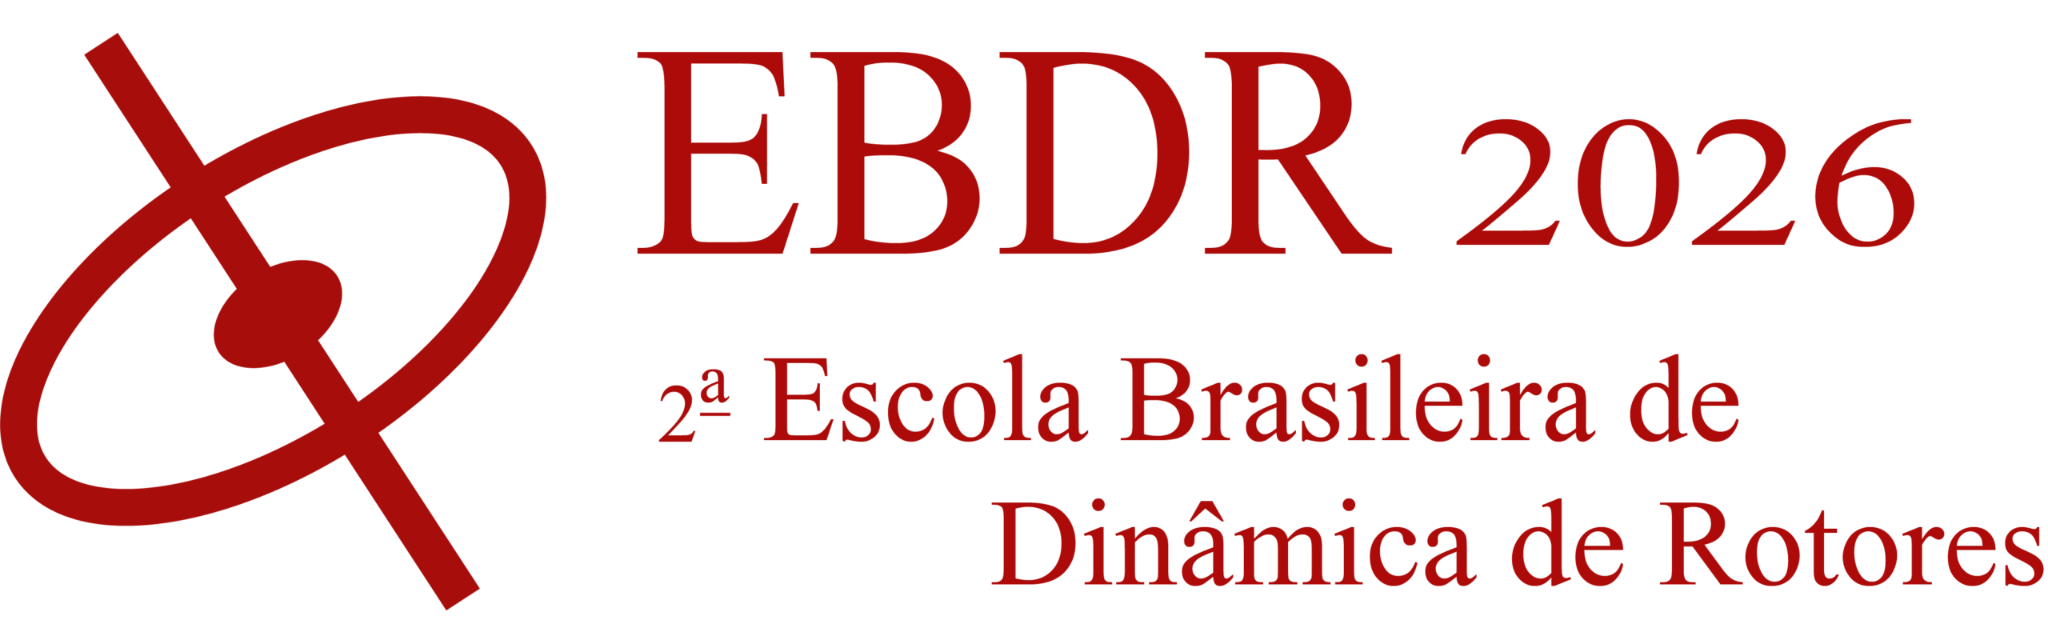&nbsp;&nbsp;4. Parâmetros
    </span>
</div>

In [ ]:
NE = 24
ND = 2
NM = 2

CD1 = 6
CD2 = 18

CMM1 = 0
CMM2 = 24

HOUSING1 = 25
HOUSING2 = 26

E = 2.0e11
RAco = 7800
RAl = 2770
Omega = 0.0

Rd = 0.06
espD = 0.011
Ri = 0.0

MasM = 0.40698
h = 0.001
b = 0.0285
lr = 0.075

Rext = 0.0025
Rint = 0.0

print("NE =", NE)
print("Discos nos nós:", CD1, CD2)
print("Mancais nos nós:", CMM1, CMM2)
print("Housing:", HOUSING1, HOUSING2)


<div style="
    display:flex;
    align-items:center;
    background:linear-gradient(90deg, #ffffff, #ffffff);
    border-left:8px solid #c00000;
    width:99%;
    padding:10px 14px;
    border-radius:8px;
    box-sizing:border-box;
    margin:0 0 -10px 0;">
    <span style="color:#c00000;font-size:24px;font-weight:bold;font-family:Arial,sans-serif;">
        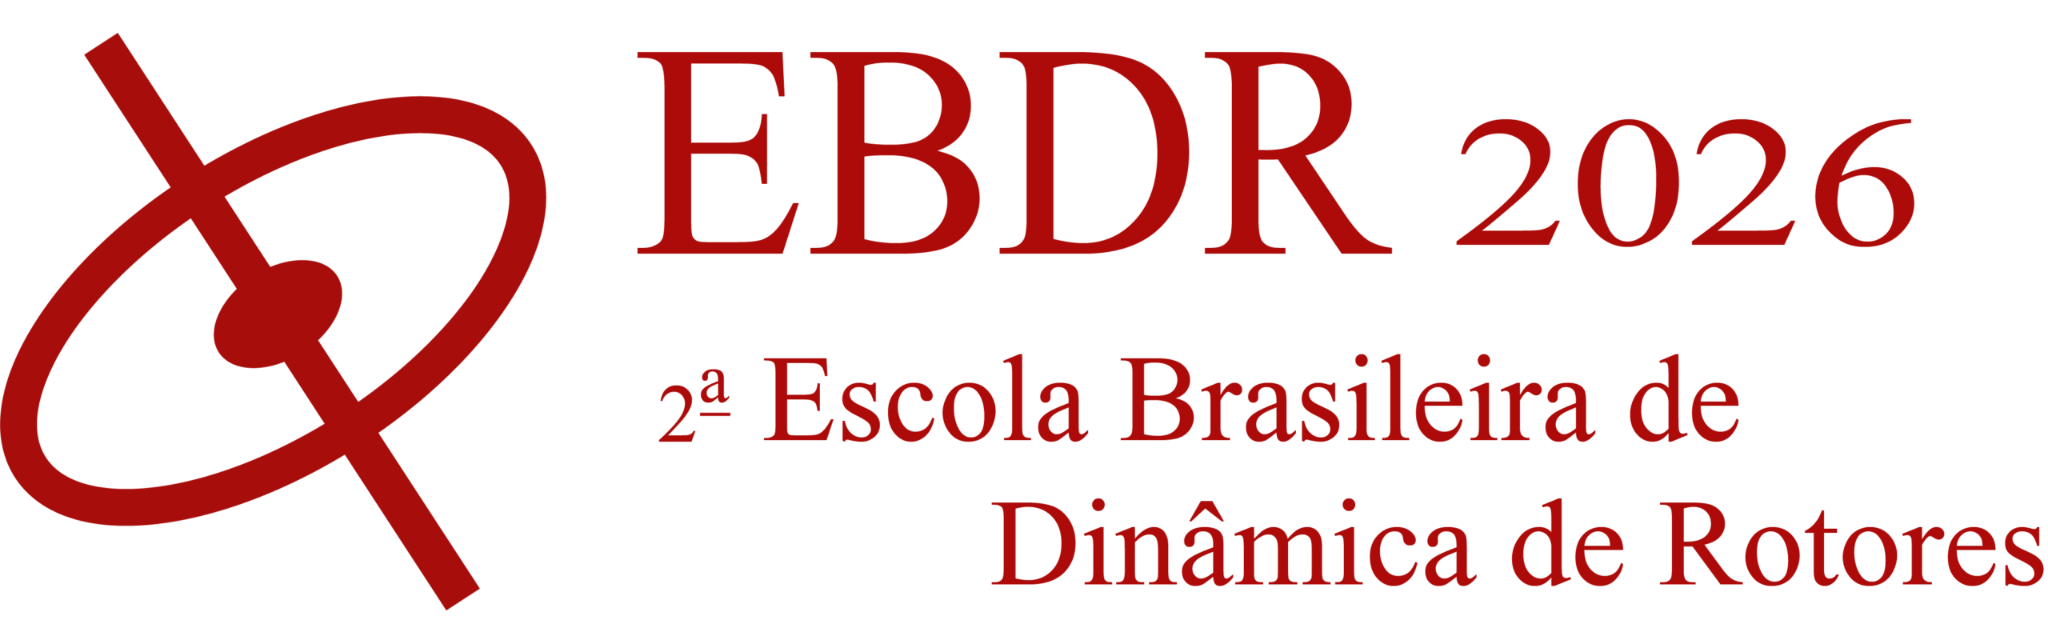&nbsp;&nbsp;5. Materiais
    </span>
</div>

In [ ]:
aluminum = rs.Material(
    name="aluminum",
    rho=2770,
    E=70e9,
    G_s=27e9,
)

steel = rs.Material(
    name="steel_DTU",
    rho=7800,
    E=2e11,
    G_s=8.0e10,
)


<div style="
    display:flex;
    align-items:center;
    background:linear-gradient(90deg, #ffffff, #ffffff);
    border-left:8px solid #c00000;
    width:99%;
    padding:10px 14px;
    border-radius:8px;
    box-sizing:border-box;
    margin:0 0 -10px 0;">
    <span style="color:#c00000;font-size:24px;font-weight:bold;font-family:Arial,sans-serif;">
        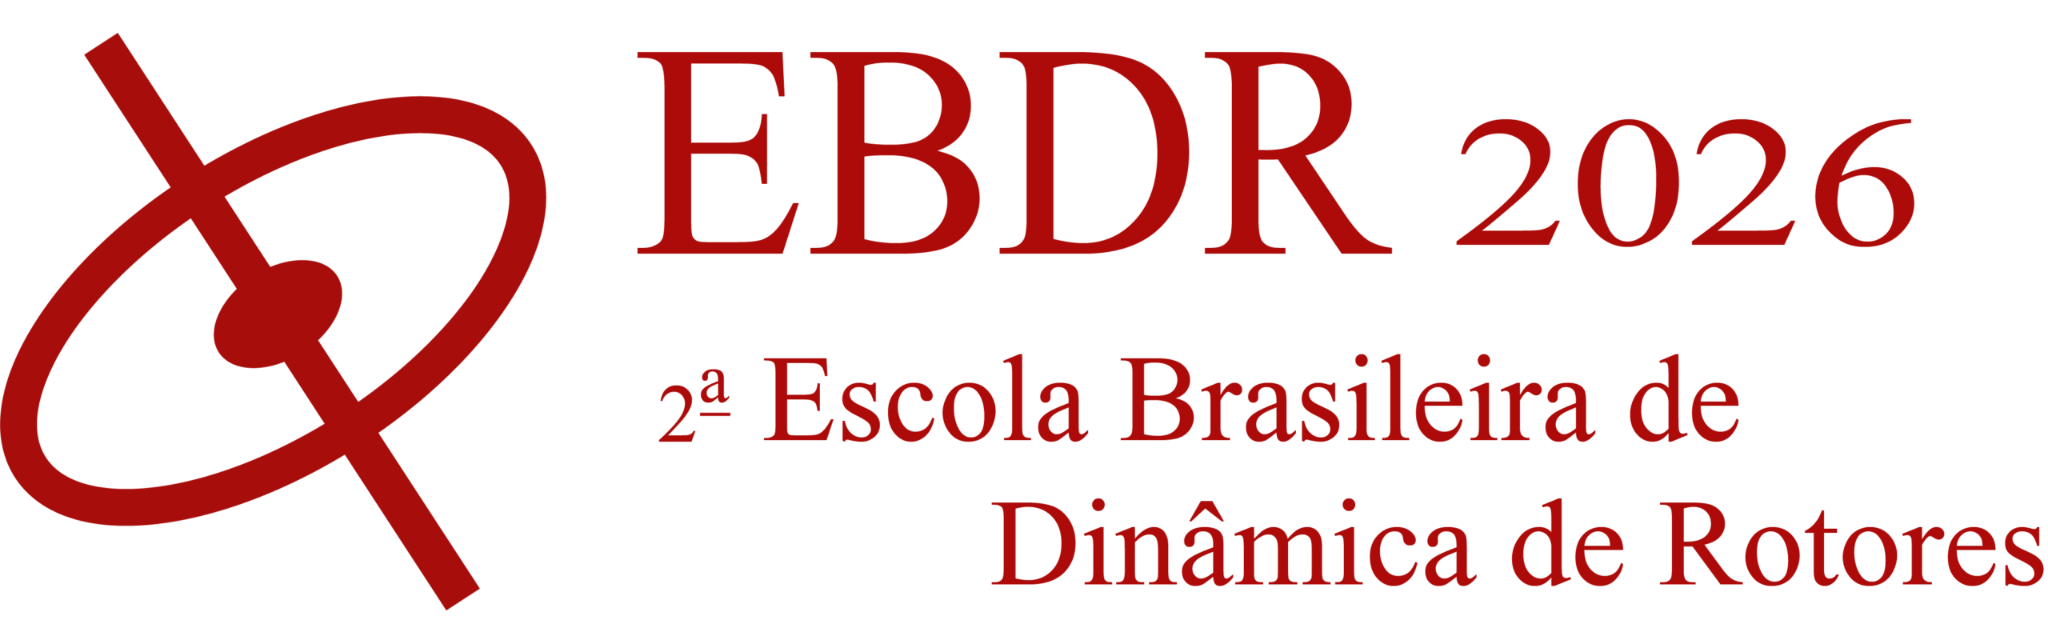&nbsp;&nbsp;6. Elementos de eixo
    </span>
</div>

In [ ]:
l = np.zeros(24)

# 6 elementos: 0.140 m
for i in range(6):
    l[i] = 0.140 / 6

# 12 elementos: 0.205 m
for i in range(6, 18):
    l[i] = 0.205 / 12

# 6 elementos: 0.090 m
for i in range(18, 24):
    l[i] = 0.090 / 6

shaft_elements = [
    rs.ShaftElement(
        L=l[i],
        idl=2 * Rint,
        odl=2 * Rext,
        material=steel,
        n=i,
        shear_effects=True,
        rotary_inertia=True,
        gyroscopic=True,
    )
    for i in range(24)
]

print(f"Comprimento total do eixo: {np.sum(l):.4f} m")
print(f"Número de elementos: {len(shaft_elements)}")


<div style="
    display:flex;
    align-items:center;
    background:linear-gradient(90deg, #ffffff, #ffffff);
    border-left:8px solid #c00000;
    width:99%;
    padding:10px 14px;
    border-radius:8px;
    box-sizing:border-box;
    margin:0 0 -10px 0;">
    <span style="color:#c00000;font-size:24px;font-weight:bold;font-family:Arial,sans-serif;">
        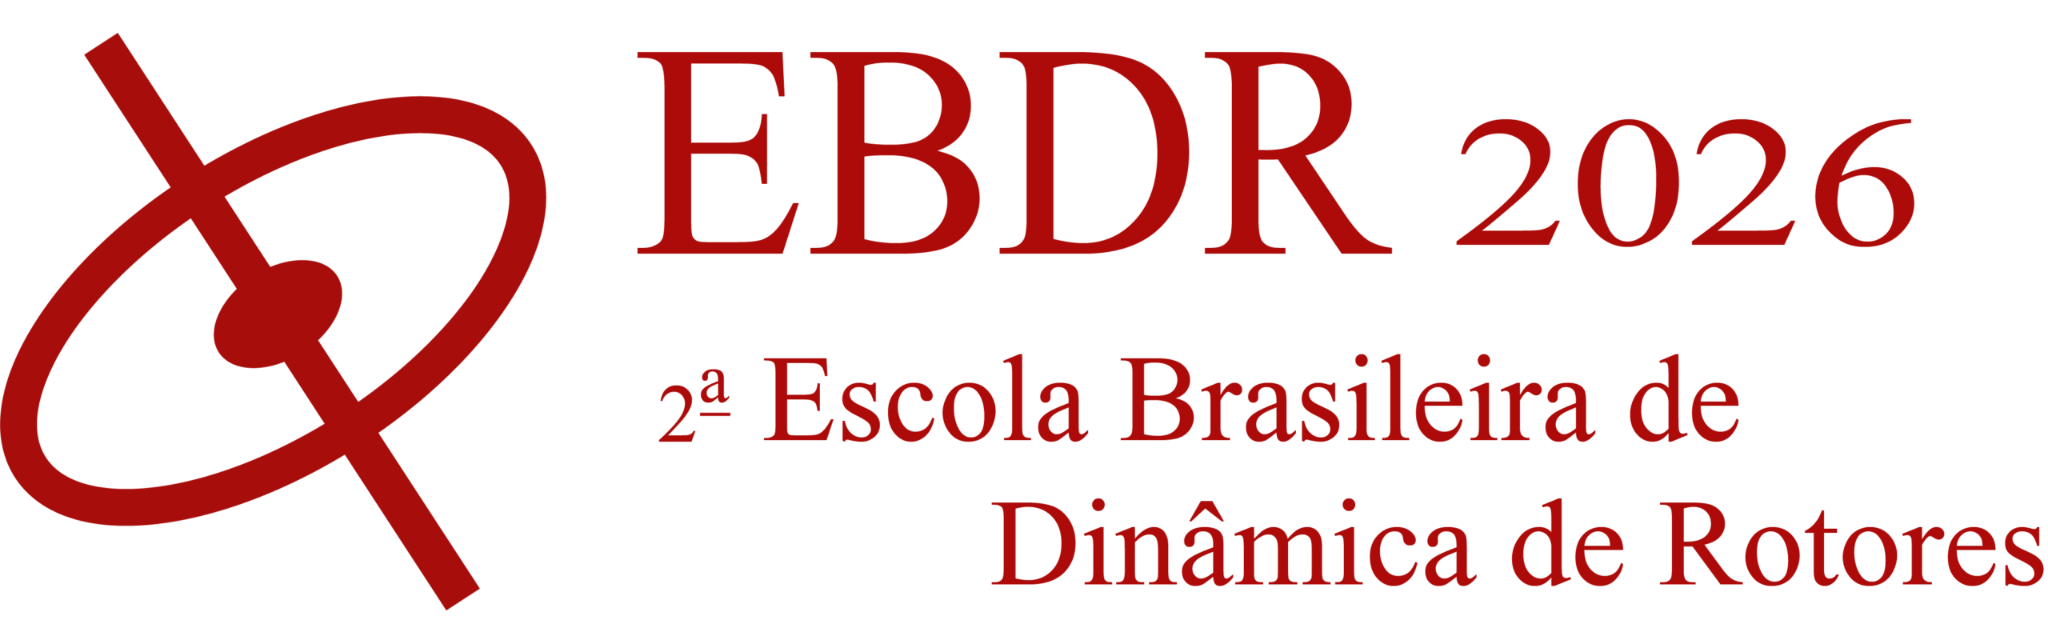&nbsp;&nbsp;7. Discos maciços
    </span>
</div>

In [ ]:
MasD = np.pi * Rd**2 * espD * RAl
Id = 1/4 * MasD * Rd**2 + 1/12 * MasD * espD**2
Ip = 1/2 * MasD * Rd**2

disk1 = rs.DiskElement.from_geometry(
    n=6,
    material=aluminum,
    width=espD,
    i_d=0,
    o_d=2 * Rd,
)

disk2 = rs.DiskElement.from_geometry(
    n=18,
    material=aluminum,
    width=espD,
    i_d=0,
    o_d=2 * Rd,
)

print(f"Disc mass: {MasD:.4f} kg")
print(f"Disc Id:   {Id:.6f} kg*m^2")
print(f"Disc Ip:   {Ip:.6f} kg*m^2")


<div style="
    display:flex;
    align-items:center;
    background:linear-gradient(90deg, #ffffff, #ffffff);
    border-left:8px solid #c00000;
    width:99%;
    padding:10px 14px;
    border-radius:8px;
    box-sizing:border-box;
    margin:0 0 -10px 0;">
    <span style="color:#c00000;font-size:24px;font-weight:bold;font-family:Arial,sans-serif;">
        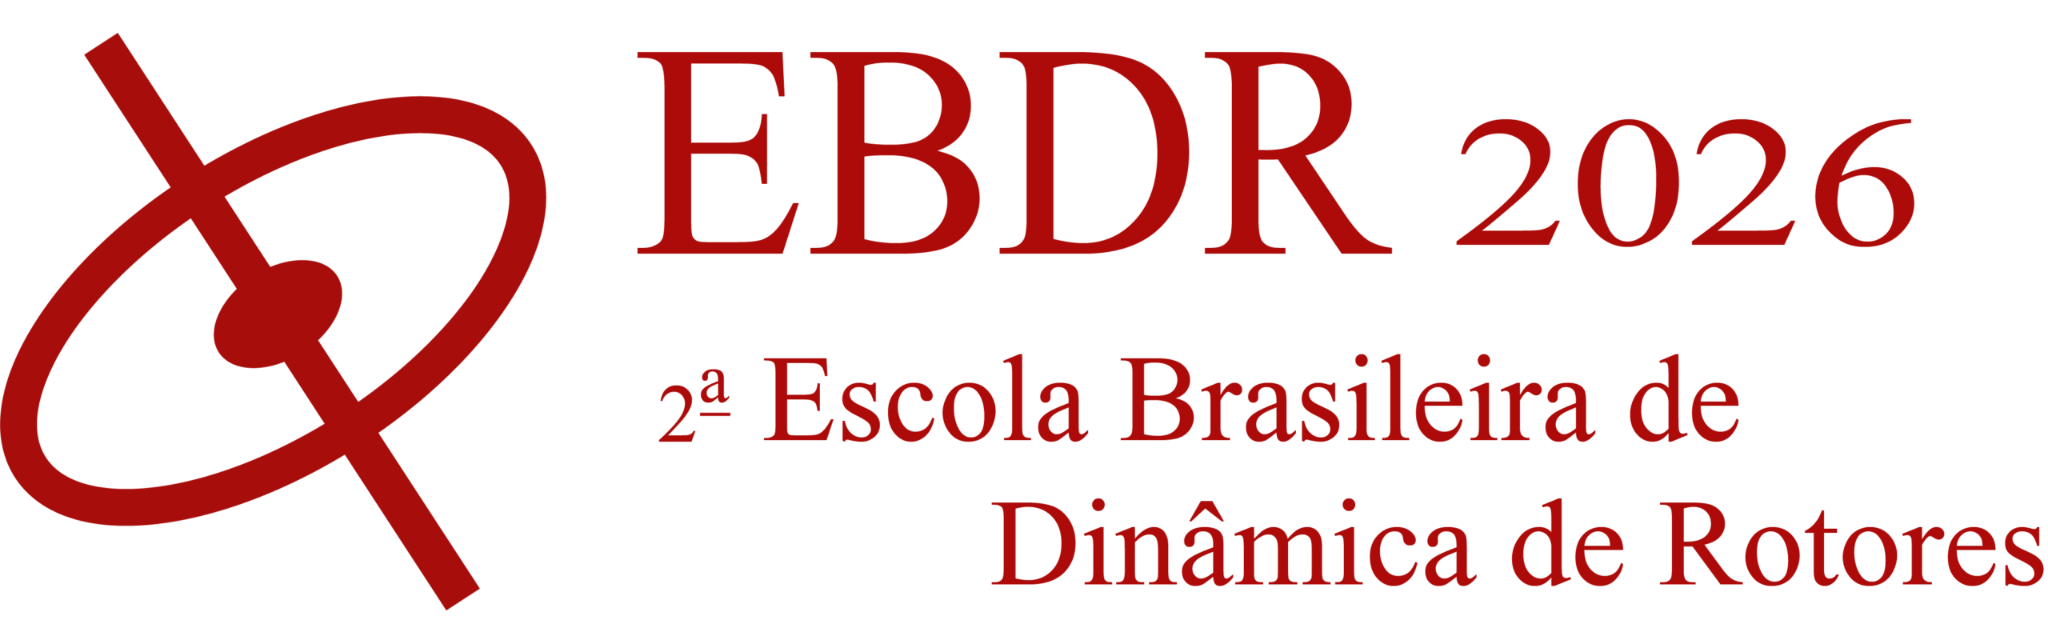&nbsp;&nbsp;8. Mancais
    </span>
</div>

In [ ]:
Area = b * h
I_beam = b * h**3 / 12

Kty0 = 2 * 12 * E * I_beam / lr**3
Ktz0 = 2 * E * Area / lr

bearing1 = rs.BearingElement(
    n=0,
    n_link=25,
    kxx=Ktz0,
    kyy=Kty0,
)

support1 = rs.BearingElement(
    n=25,
    kxx=Ktz0,
    kyy=Kty0,
)

bearing2 = rs.BearingElement(
    n=24,
    n_link=26,
    kxx=Ktz0,
    kyy=Kty0,
)

support2 = rs.BearingElement(
    n=26,
    kxx=Ktz0,
    kyy=Kty0,
)

print(f"Kty0 = {Kty0:.2f} N/m")
print(f"Ktz0 = {Ktz0:.2f} N/m")


<div style="
    display:flex;
    align-items:center;
    background:linear-gradient(90deg, #ffffff, #ffffff);
    border-left:8px solid #c00000;
    width:99%;
    padding:10px 14px;
    border-radius:8px;
    box-sizing:border-box;
    margin:0 0 -10px 0;">
    <span style="color:#c00000;font-size:24px;font-weight:bold;font-family:Arial,sans-serif;">
        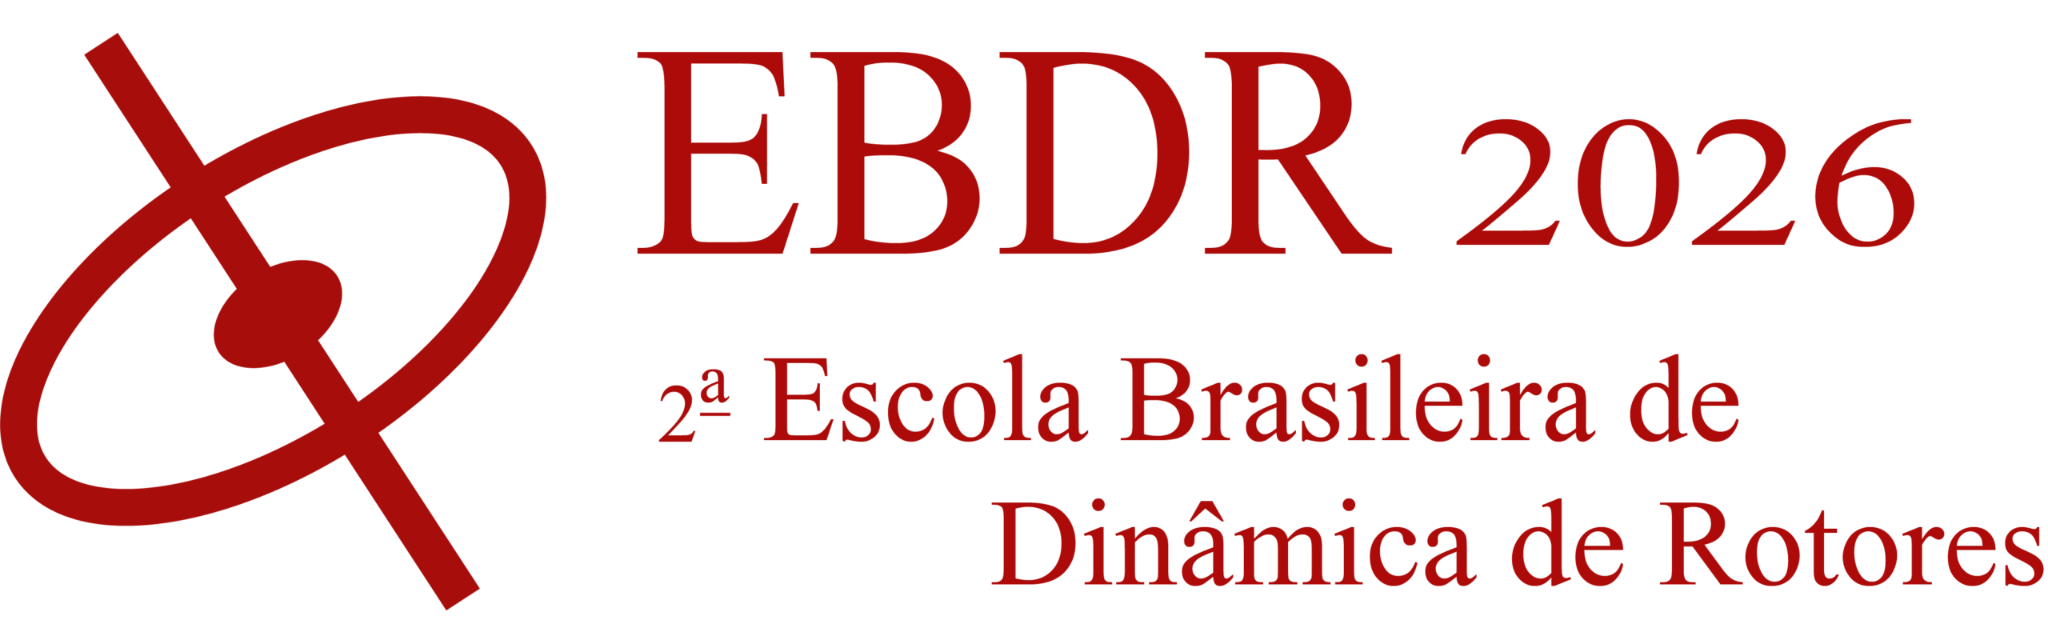&nbsp;&nbsp;9. Montagem + conversão para 4 DOF
    </span>
</div>

In [ ]:
point_mass1 = rs.PointMass(n=25, m=MasM)
point_mass2 = rs.PointMass(n=26, m=MasM)

rotor = rs.Rotor(
    shaft_elements,
    [disk1, disk2],
    [bearing1, support1, bearing2, support2],
    [point_mass1, point_mass2],
)

rotor_4dof = convert_6dof_to_4dof(rotor)

print("Rotor montado.")
print("Nós:", len(rotor.nodes))
print("DOFs do modelo original:", rotor.ndof)
print("DOFs do modelo 4 DOF:", rotor_4dof.ndof)

rotor.plot_rotor(nodes=999).show()


<div style="
    display:flex;
    align-items:center;
    background:linear-gradient(90deg, #ffffff, #ffffff);
    border-left:8px solid #c00000;
    width:99%;
    padding:10px 14px;
    border-radius:8px;
    box-sizing:border-box;
    margin:0 0 -10px 0;">
    <span style="color:#c00000;font-size:24px;font-weight:bold;font-family:Arial,sans-serif;">
        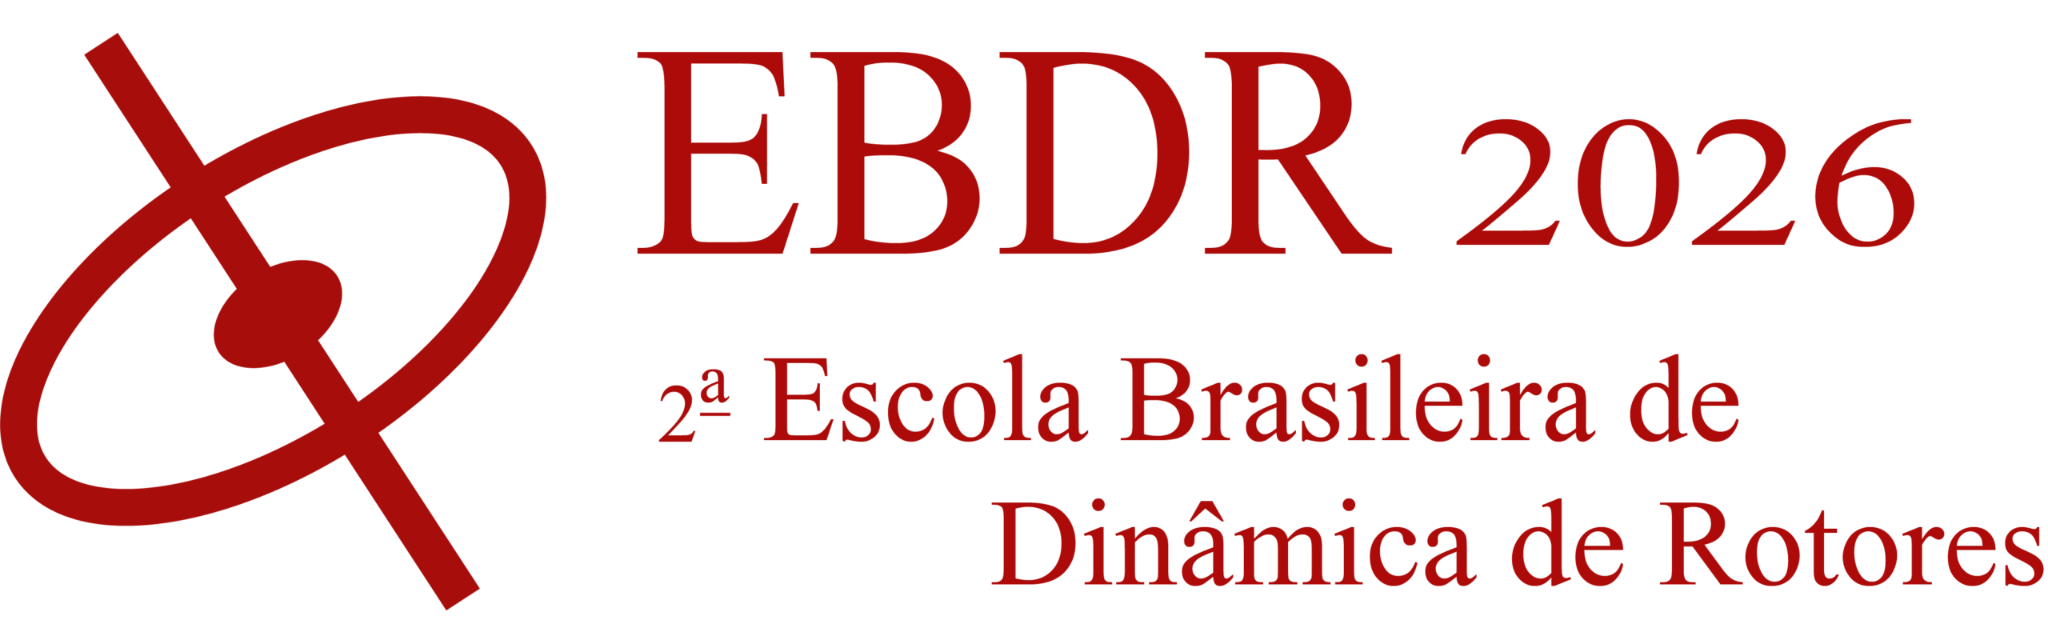&nbsp;&nbsp;10. Análise modal
    </span>
</div>

In [ ]:
modal = rotor_4dof.run_modal(speed=Omega)
wn_hz = modal.wn / (2 * np.pi)

print("Primeiros 20 modos naturais:")
for i, freq in enumerate(wn_hz[:20]):
    print(f"  Modo {i + 1}: {freq:.2f} Hz")

for mode_num in range(1, min(7, len(wn_hz) + 1)):
    fig = modal.plot_mode_3d(mode=mode_num)
    fig.update_layout(
        title=f"Modo {mode_num} - f={wn_hz[mode_num-1]:.2f} Hz"
    )
    fig.show()


<div style="
    display:flex;
    align-items:center;
    background:linear-gradient(90deg, #ffffff, #ffffff);
    border-left:8px solid #c00000;
    width:99%;
    padding:10px 14px;
    border-radius:8px;
    box-sizing:border-box;
    margin:0 0 -10px 0;">
    <span style="color:#c00000;font-size:24px;font-weight:bold;font-family:Arial,sans-serif;">
        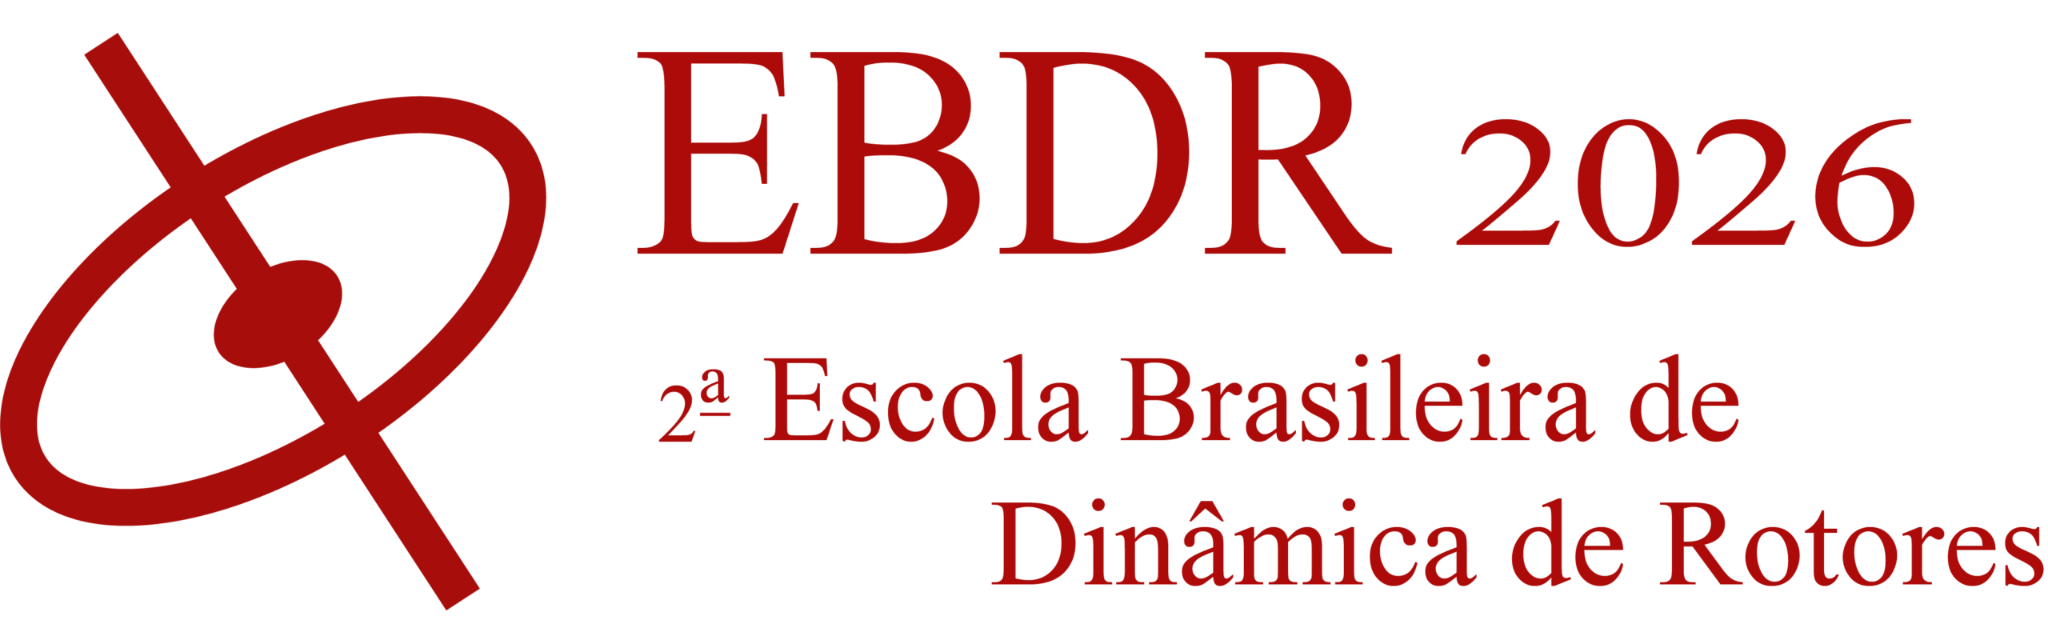&nbsp;&nbsp;11. Diagrama de Campbell
    </span>
</div>

In [ ]:
speed_range = np.linspace(0, 3000 * 2 * np.pi / 60, 50)

campbell = rotor_4dof.run_campbell(speed_range)

campbell.plot().show()


<div style="
    display:flex;
    align-items:center;
    background:linear-gradient(90deg, #ffffff, #ffffff);
    border-left:8px solid #c00000;
    width:99%;
    padding:10px 14px;
    border-radius:8px;
    box-sizing:border-box;
    margin:0 0 -10px 0;">
    <span style="color:#c00000;font-size:24px;font-weight:bold;font-family:Arial,sans-serif;">
        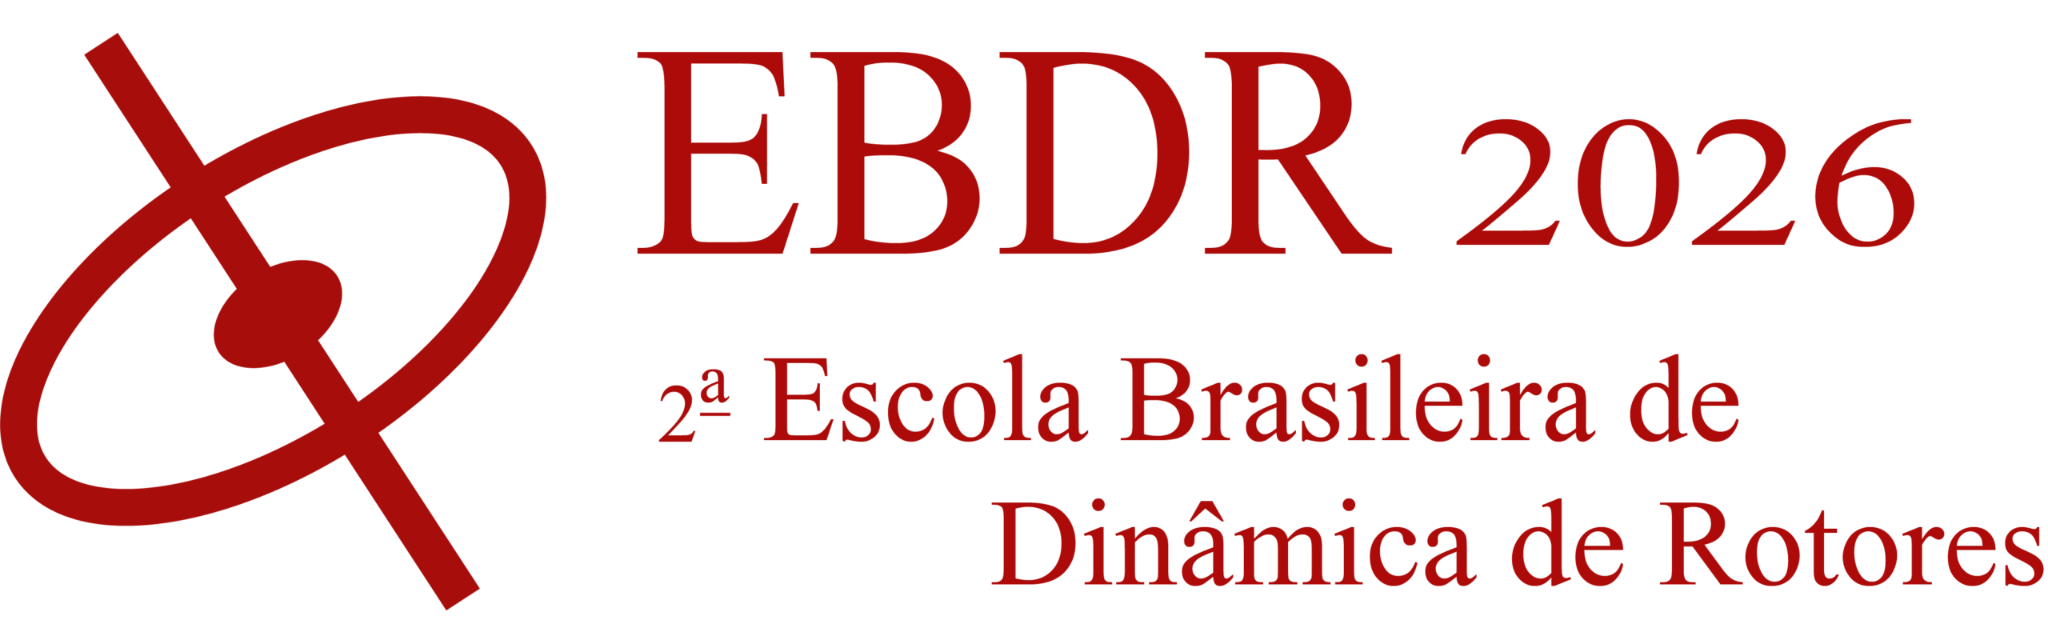&nbsp;&nbsp;12. Velocidades críticas
    </span>
</div>

In [ ]:
critical = rotor_4dof.run_critical_speed(num_modes=12)

print(critical)


<div style="
    display:flex;
    align-items:center;
    background:linear-gradient(90deg, #ffffff, #ffffff);
    border-left:8px solid #c00000;
    width:99%;
    padding:10px 14px;
    border-radius:8px;
    box-sizing:border-box;
    margin:0 0 -10px 0;">
    <span style="color:#c00000;font-size:24px;font-weight:bold;font-family:Arial,sans-serif;">
        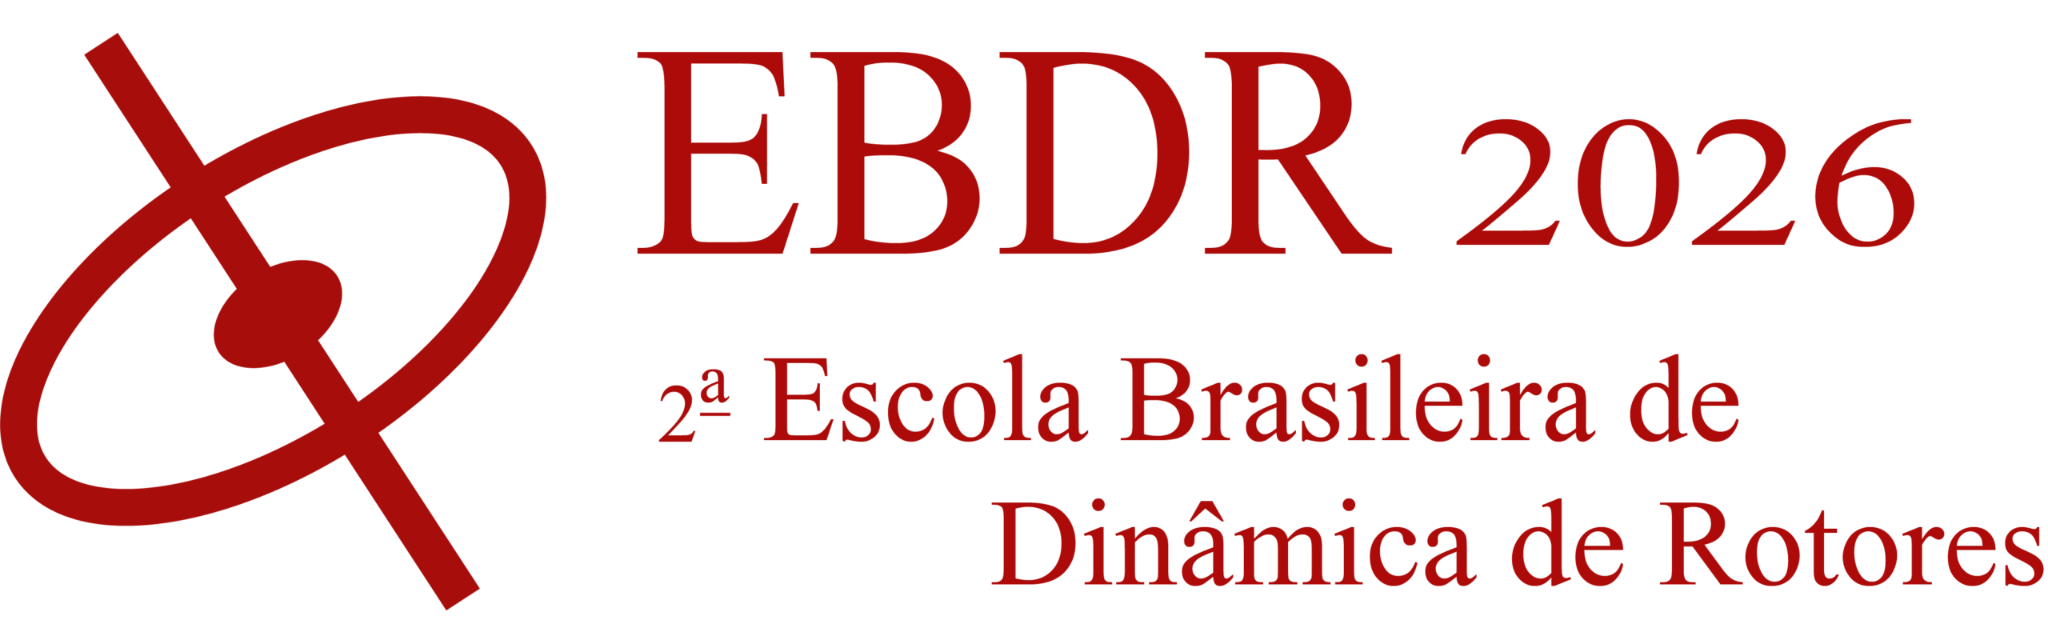&nbsp;&nbsp;13. Resposta em frequência (FRF)
    </span>
</div>

In [ ]:
omega = np.linspace(0.1, 500, 500)

freq_resp = rotor_4dof.run_freq_response(
    speed_range=omega
)

freq_resp.plot_magnitude(inp=25, out=25).show()
freq_resp.plot_phase(inp=25, out=25).show()
freq_resp.plot_polar_bode(inp=25, out=25).show()


<div style="
    display:flex;
    align-items:center;
    background:linear-gradient(90deg, #ffffff, #ffffff);
    border-left:8px solid #c00000;
    width:99%;
    padding:10px 14px;
    border-radius:8px;
    box-sizing:border-box;
    margin:0 0 -10px 0;">
    <span style="color:#c00000;font-size:24px;font-weight:bold;font-family:Arial,sans-serif;">
        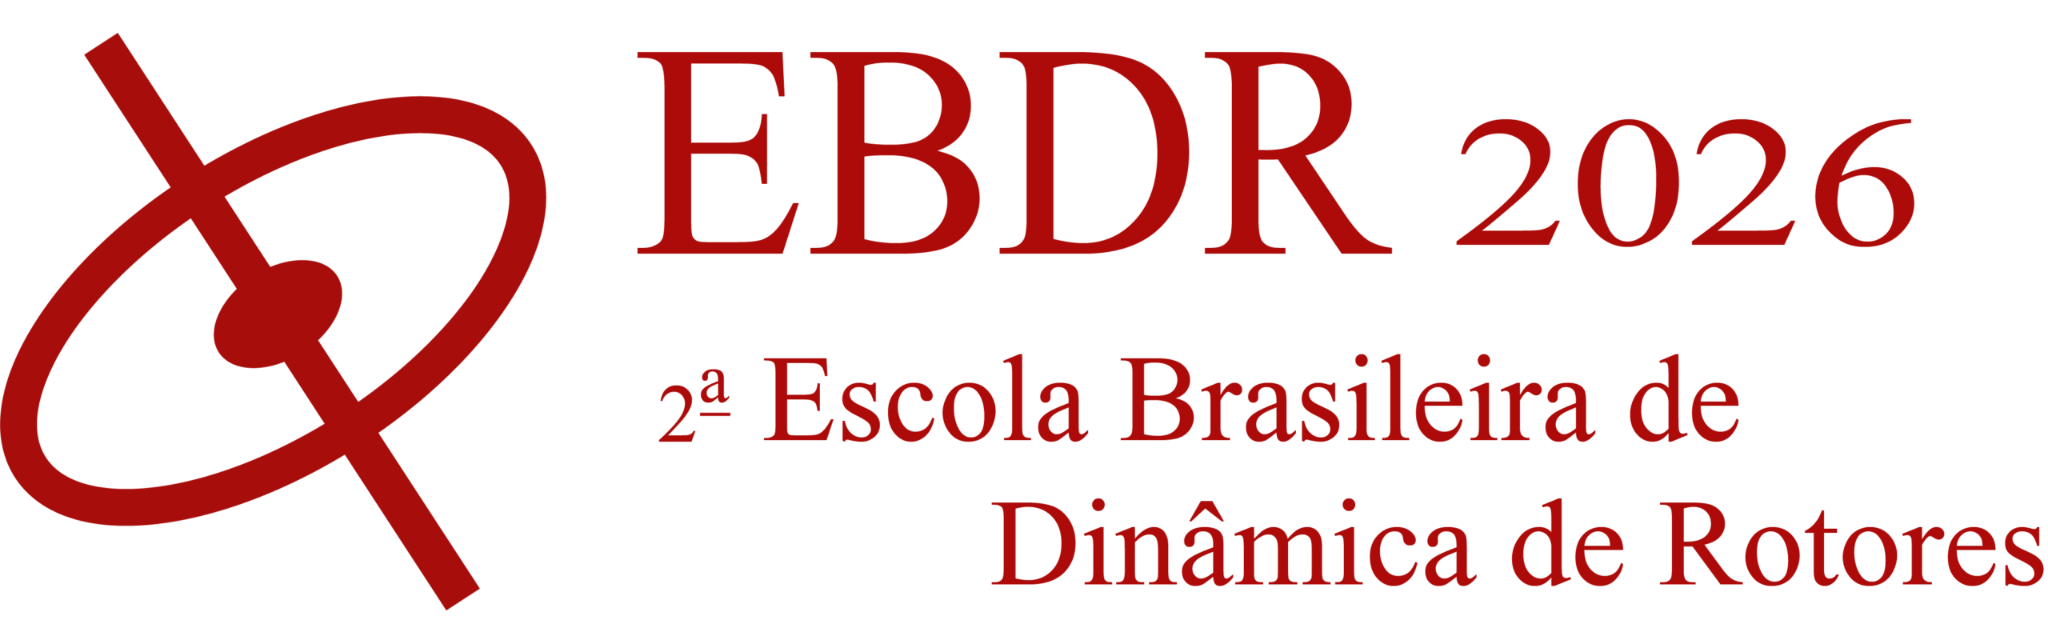&nbsp;&nbsp;14. Resposta a desbalanceamento
    </span>
</div>

In [ ]:
unb_resp = rotor_4dof.run_unbalance_response(
    node=[6, 18],
    magnitude=[0.001, 0.001],
    phase=[0, 0],
    frequency=omega,
)

unb_resp.plot_magnitude(probe=6).show()
unb_resp.plot_bode(probe=6).show()
unb_resp.plot_deflected_shape(
    speed=100 * 2 * np.pi / 60
).show()


<div style="
    display:flex;
    align-items:center;
    background:linear-gradient(90deg, #ffffff, #ffffff);
    border-left:8px solid #c00000;
    width:99%;
    padding:10px 14px;
    border-radius:8px;
    box-sizing:border-box;
    margin:0 0 -10px 0;">
    <span style="color:#c00000;font-size:24px;font-weight:bold;font-family:Arial,sans-serif;">
        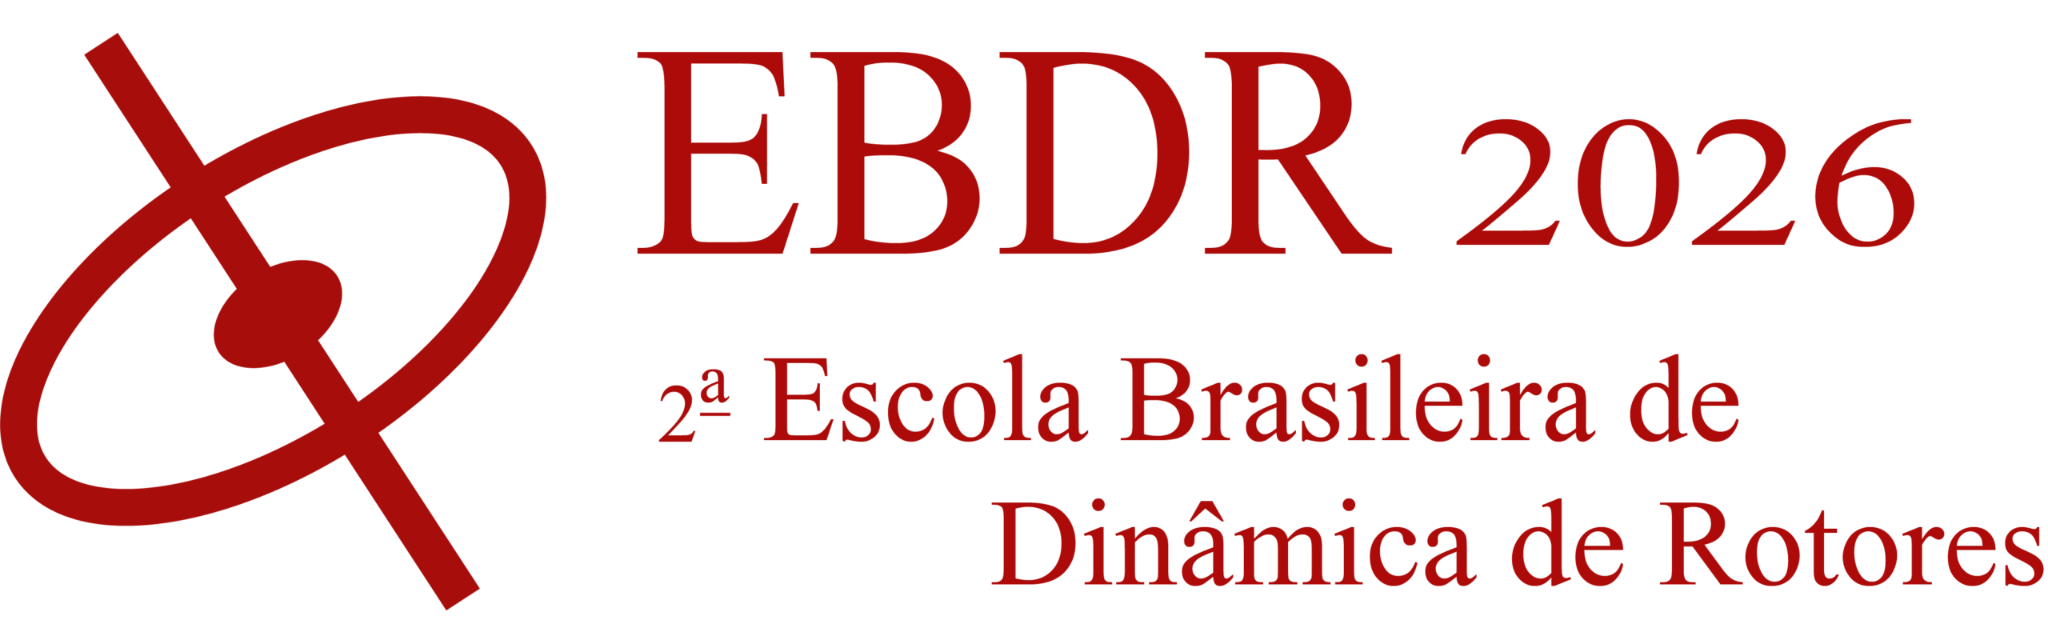&nbsp;&nbsp;15. Resposta no tempo
    </span>
</div>

In [ ]:
speed = 100 * 2 * np.pi / 60
t = np.linspace(0, 10, 10001)

F = np.zeros(
    (len(t), rotor_4dof.ndof),
    dtype=complex,
)

time_resp = rotor_4dof.run_time_response(
    speed,
    F,
    t,
    method="newmark",
)

time_resp.plot_1d(probe=6).show()
time_resp.plot_dfft(probe=6).show()


<div style="
    display:flex;
    align-items:center;
    background:linear-gradient(90deg, #ffffff, #ffffff);
    border-left:8px solid #c00000;
    width:99%;
    padding:10px 14px;
    border-radius:8px;
    box-sizing:border-box;
    margin:0 0 -10px 0;">
    <span style="color:#c00000;font-size:24px;font-weight:bold;font-family:Arial,sans-serif;">
        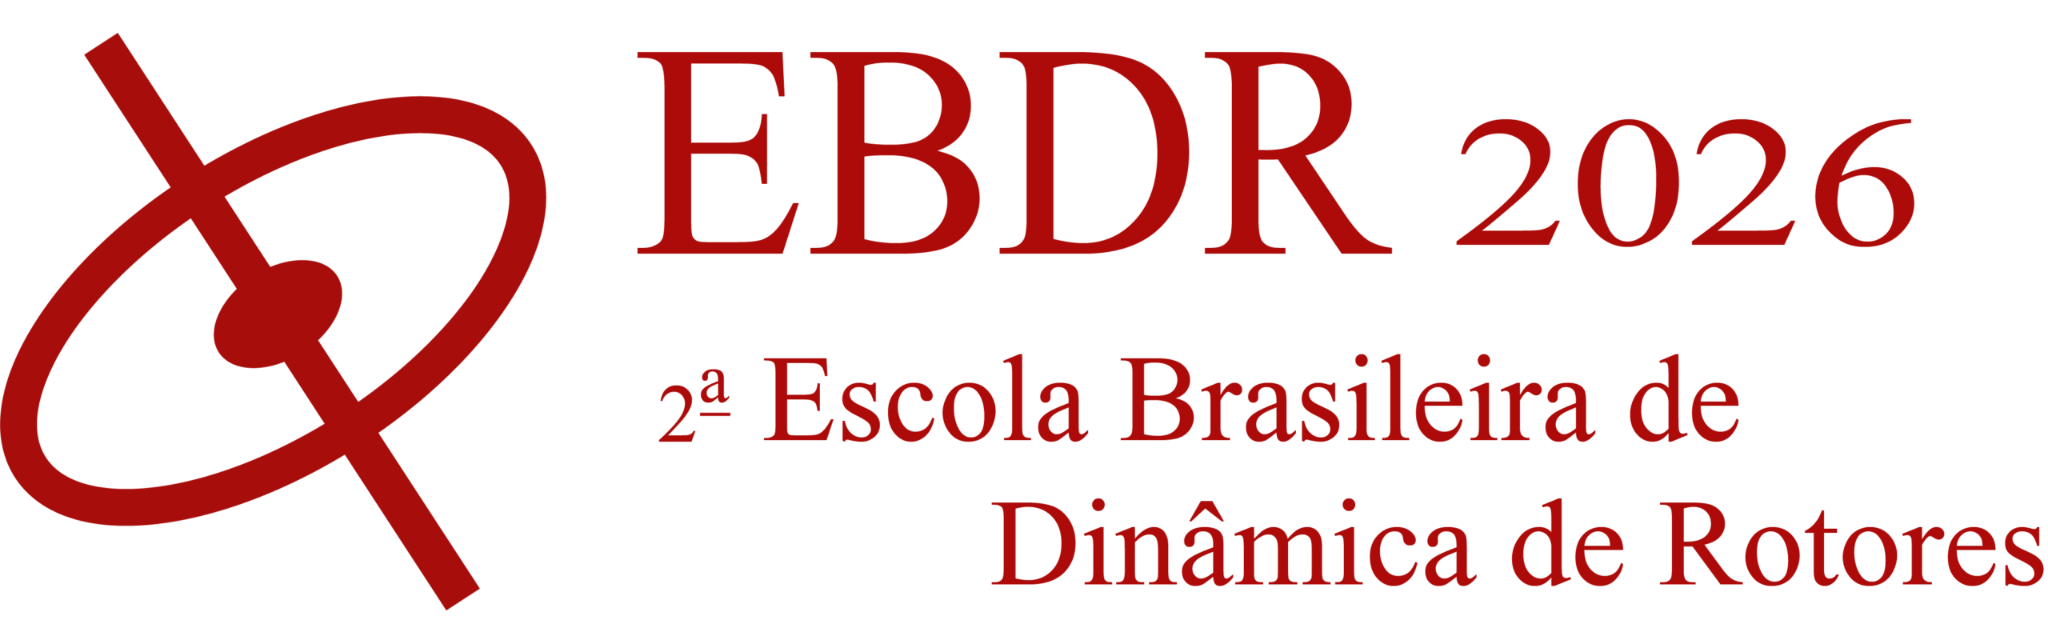&nbsp;&nbsp;16. Tabela de validação
    </span>
</div>

In [ ]:
experimental = np.array([13.0, 14.9, 33.6, 43.0, 46.0])

validation = pd.DataFrame({
    "Experimental (Hz)": experimental,
    "ROSS (Hz)": wn_hz[:5],
})

validation["Erro absoluto (Hz)"] = (
    validation["ROSS (Hz)"] - validation["Experimental (Hz)"]
).abs()

validation["Erro relativo (%)"] = (
    validation["Erro absoluto (Hz)"]
    / validation["Experimental (Hz)"]
    * 100
)

validation


**Valores experimentais de referência:** 13.0, 14.9, 33.6, 43.0, 46.0 Hz

A tabela acima permite avaliar quantitativamente a concordância entre o modelo numérico e o ensaio DTU.


<div style="
    display:flex;
    align-items:center;
    background:linear-gradient(90deg, #ffffff, #ffffff);
    border-left:8px solid #c00000;
    width:99%;
    padding:10px 14px;
    border-radius:8px;
    box-sizing:border-box;
    margin:0 0 -10px 0;">
    <span style="color:#c00000;font-size:24px;font-weight:bold;font-family:Arial,sans-serif;">
        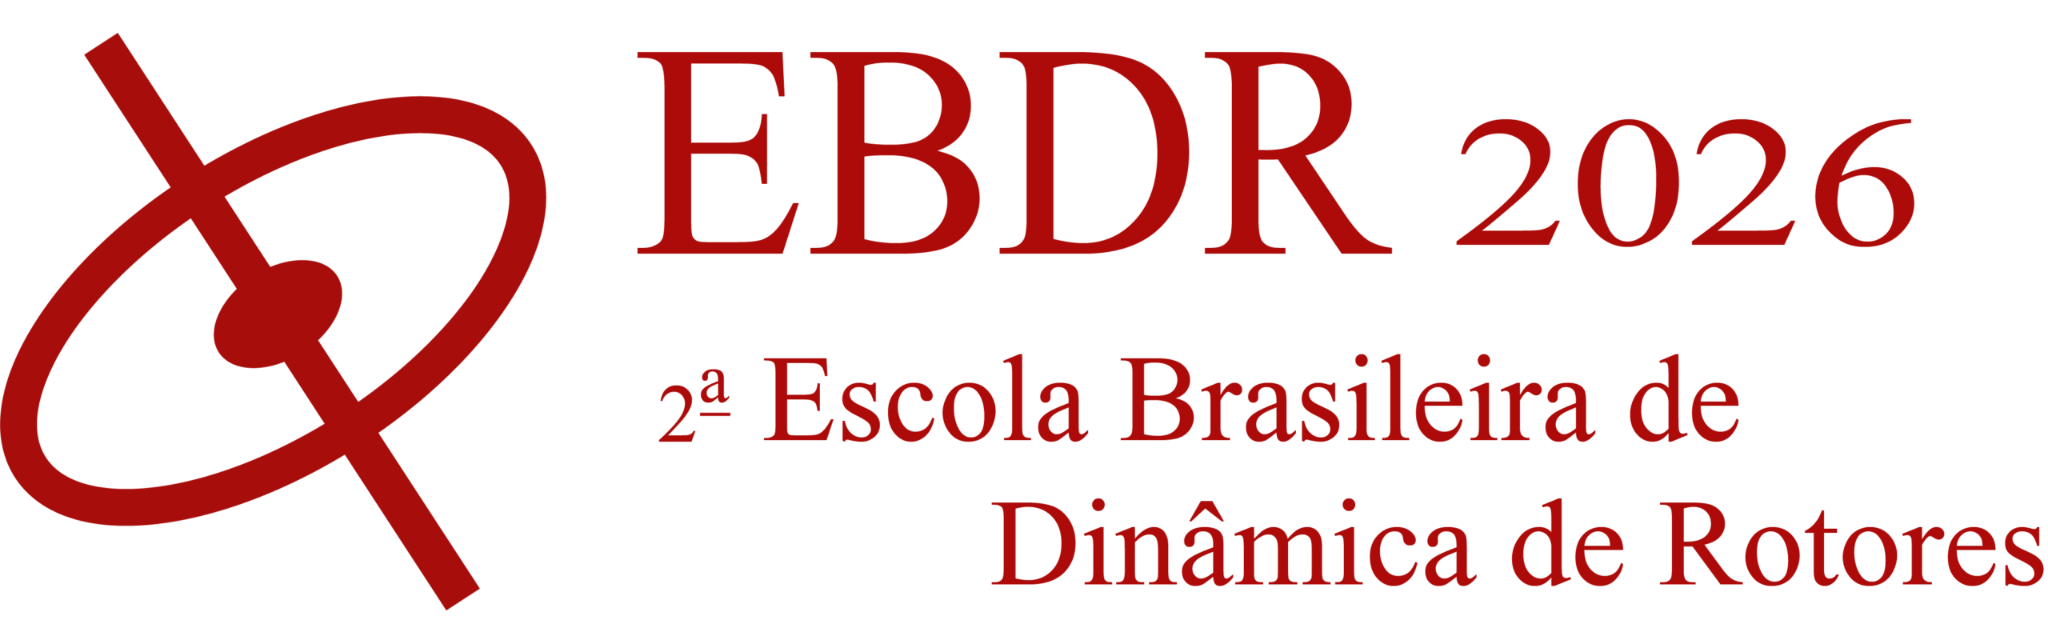&nbsp;&nbsp;17. Atividades
    </span>
</div>

As atividades a seguir foram organizadas para consolidar a interpretação física dos resultados e a utilização do modelo ROSS.

<div style="
    background:#ffffff;
    border:4px solid #ffffff;
    border-radius:8px;
    padding:16px;
    font-family:Arial,sans-serif;">
    <h3>Atividades</h3>
<ol>
<li>Execute a análise modal e identifique os cinco primeiros modos associados à faixa experimental.</li>
<li>Compare cada frequência numérica com os valores experimentais de 13.0, 14.9, 33.6, 43.0 e 46.0 Hz.</li>
<li>Calcule o erro relativo de cada frequência e indique qual modo apresenta a maior discrepância.</li>
<li>Observe o diagrama de Campbell e identifique as regiões em que as linhas de excitação podem cruzar as frequências naturais.</li>
<li>Na resposta a desbalanceamento, explique por que a amplitude cresce nas proximidades das velocidades críticas.</li>
<li>Compare a discretização deste modelo com uma malha mais grosseira e discuta a influência do número de elementos sobre os modos superiores.</li>
</ol>
</div>

<div style="
    display:flex;
    align-items:center;
    background:linear-gradient(90deg, #ffffff, #ffffff);
    border-left:8px solid #c00000;
    width:99%;
    padding:10px 14px;
    border-radius:8px;
    box-sizing:border-box;
    margin:0 0 -10px 0;">
    <span style="color:#c00000;font-size:24px;font-weight:bold;font-family:Arial,sans-serif;">
        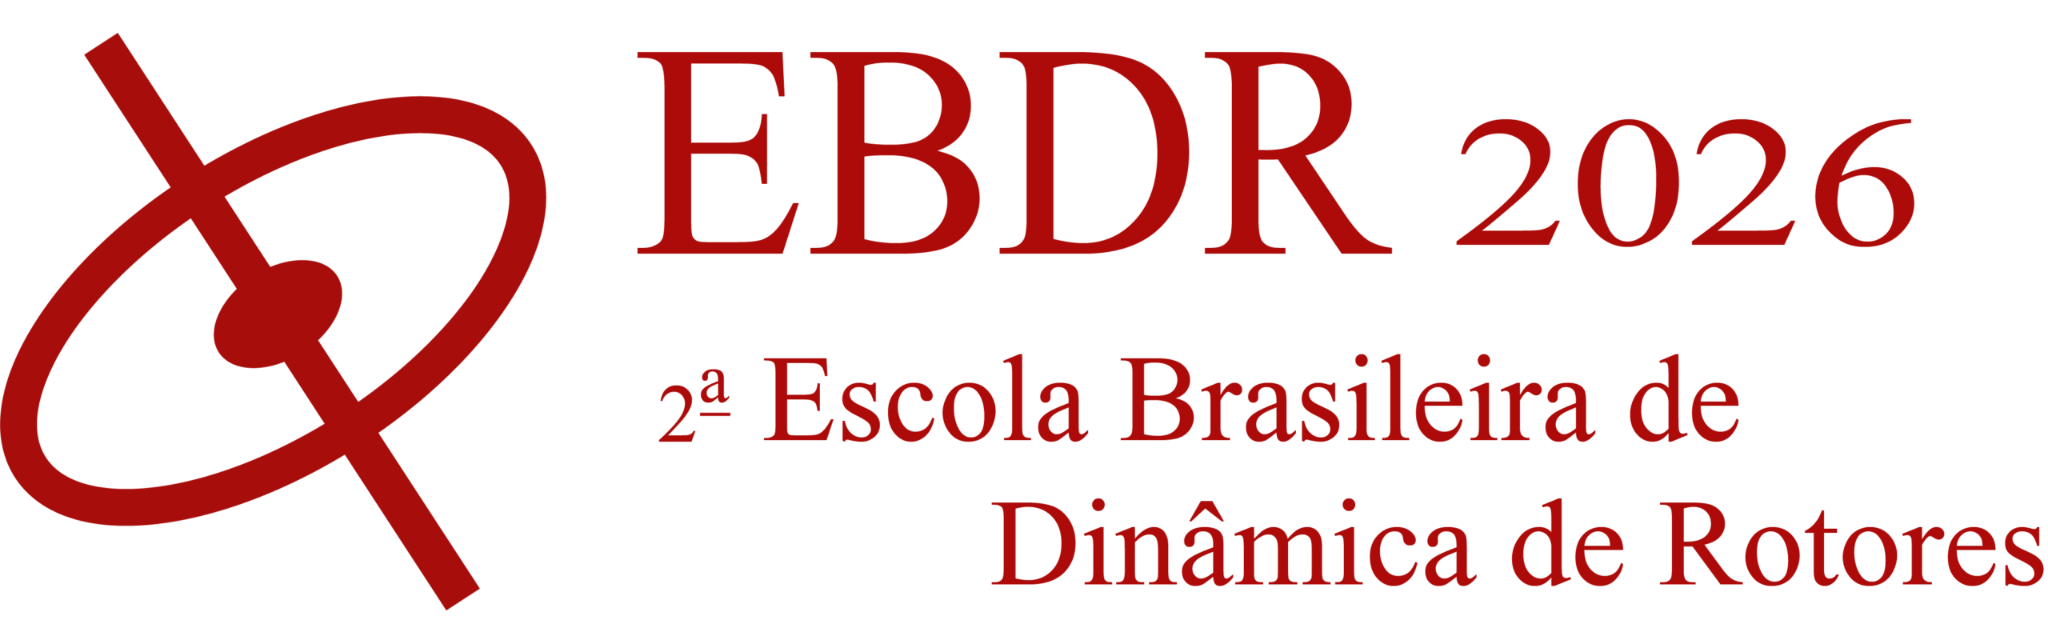&nbsp;&nbsp;18. Gabarito
    </span>
</div>

<div style="
    background:#fafafa;
    border:1px solid #ddd;
    border-radius:8px;
    padding:16px;
    font-family:Arial,sans-serif;">
    <h3>Gabarito orientativo</h3>
<p><b>1.</b> Execute <code>run_modal</code> e utilize <code>wn_hz</code> para listar as frequências naturais. A identificação dos modos deve ser feita pela proximidade com os valores experimentais e pela inspeção das formas modais.</p>
<p><b>2.</b> Os valores de referência são 13.0, 14.9, 33.6, 43.0 e 46.0 Hz. A comparação deve ser feita modo a modo, respeitando a ordem das frequências.</p>
<p><b>3.</b> Use <code>|f_num - f_exp| / f_exp × 100</code>. O maior valor corresponde ao pior ajuste relativo.</p>
<p><b>4.</b> No Campbell, velocidades críticas aparecem associadas aos cruzamentos entre as frequências naturais dependentes da velocidade e as linhas de excitação de ordem 1×, 2× etc.</p>
<p><b>5.</b> Próximo de uma ressonância, a função de resposta dinâmica apresenta aumento de amplitude devido à proximidade entre a frequência de excitação e uma frequência natural do sistema.</p>
<p><b>6.</b> O refinamento da malha aumenta a capacidade do modelo de representar curvaturas espaciais mais complexas. Por isso, a convergência dos modos superiores tende a ser particularmente sensível ao número de elementos.</p>
<p><b>Observação:</b> os resultados numéricos exatos dependem da versão do ROSS e do ambiente em que o notebook for executado; portanto, o gabarito deve ser interpretado em termos do procedimento e da tendência física esperada.</p>
</div>